# Assignment 5

### <span style="color:chocolate"> Submission requirements </span>

Your work will not be graded if your notebook doesn't include output. In other words, <span style="color:red"> make sure to rerun your notebook before submitting to Gradescope </span> (Note: if you are using Google Colab: go to Edit > Notebook Settings  and uncheck Omit code cell output when saving this notebook, otherwise the output is not printed).

Additional points may be deducted if these requirements are not met:
    
* Comment your code;
* Each graph should have a title, labels for each axis, and (if needed) a legend. Each graph should be understandable on its own;
* Try and minimize the use of the global namespace (meaning, keep things inside functions).

Additional notes:

* Please note that in this assignment, students are expected to work independently. As a result, no two solutions should look identical in terms of coding;
* You may import any libraries you need to complete the assignment. However, you must implement the model using TensorFlow (do not use PyTorch);
* Follow the same steps/idea as in Assignment 4; the difference here is that you extend a logistic model to more than two classes;
* <span style="color:chocolate"> Focus on the execution of the task rather than model performance </span> (this is how the TA will grade your work);
* Even though the prediction performance for your chosen outcome is low, it doesn't necessarily mean there is something wrong with your implementation. It could also be that the data is not supportive enough for your prediction task... again, focus on the learning opportunity and not the numbers you get;
* Your instructional team has extensive experience developing and running ML models. Often, we encounter situations where a model doesn't perform well on a predictive task. This can happen due to the nature of the data or the need for significant tweaking of variables to achieve good results;
* Do not spend significantly more time on this task than you did on Assignment 4, unless you wish to experiment and learn more.
---

``Objective``
* Perform multiclass classification using logistic regression. <span style="color:chocolate"> You will choose the outcome of interest. </span>

``Motivation``
* Chocolate is one of the most popular candies in the world. Each year, residents of the United States collectively eat more than 2.8 billions pounds (Source: Kaggle). However, not all chocolate bars are created equal! In this assignment, you will have the opportunity to delve into the world of chocolate by choosing your own machine learning task. 


``Data``

* The [Chocolate Bar dataset](https://www.kaggle.com/datasets/rtatman/chocolate-bar-ratings) contains expert ratings of 1,795 individual chocolate bars, along with information on their regional origin, percentage of cocoa, the variety of chocolate bean used and where the beans were grown (Source: Kaggle).

### Import libraries

In [1]:
%reset -f
from __future__ import print_function

import math
import numpy as np
import numpy.linalg as nla
import pandas as pd
import re
import six
from os.path import join
import tensorflow as tf
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import keras_tuner as kt
from keras_tuner import HyperParameters

# feel free to import other libraries as needed

import warnings
warnings.filterwarnings('ignore')

/opt/conda/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/conda/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (
2026-02-15 07:41:38.486853: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-15 07:41:38.490935: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-15 07:41:38.503152: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-15 07:41:38.522854: E exter

### Define functions

In [2]:
def read_data():
    ''''''
    # Read data
    df = pd.read_csv(
        "https://download.mlcc.google.com/mledu-datasets/flavors_of_cacao.csv",
        sep=",",
        encoding='latin-1'
    )
    
    return df

In [3]:
def clean_data(df):
    ''''''
    # Set the output display to have one digit for decimal places and limit it to
    # printing 15 rows.
    pd.options.display.float_format = '{:.2f}'.format
    pd.options.display.max_rows = 15
    
    # Rename the columns.
    df.columns = [
        'maker', 'specific_origin', 'reference_number',
        'review_date', 'cocoa_percent', 'maker_location',
        'rating', 'bean_type', 'broad_origin'
    ]

    # df.dtypes

    # Replace empty/null values with "Blend"
    df['bean_type'] = df['bean_type'].fillna('Blend')

    # Cast bean_type to string to remove leading 'u'
    df['bean_type'] = df['bean_type'].astype(str)
    df['cocoa_percent'] = df['cocoa_percent'].str.strip('%')
    df['cocoa_percent'] = pd.to_numeric(df['cocoa_percent'])

    # Correct spelling mistakes, and replace city with country name
    df['maker_location'] = df['maker_location']\
    .str.replace('Amsterdam', 'Holland')\
    .str.replace('U.K.', 'England')\
    .str.replace('Niacragua', 'Nicaragua')\
    .str.replace('Domincan Republic', 'Dominican Republic')\
    .str.replace('Eucador', 'Ecuador')

    # Adding this so that Holland and Netherlands map to the same country.
    df['maker_location'] = df['maker_location']\
    .str.replace('Holland', 'Netherlands')

    def cleanup_spelling_abbrev(text):
        replacements = [
            ['-', ', '], ['/ ', ', '], ['/', ', '], ['\(', ', '], [' and', ', '], [' &', ', '], ['\)', ''],
            ['Dom Rep|DR|Domin Rep|Dominican Rep,|Domincan Republic', 'Dominican Republic'],
            ['Mad,|Mad$', 'Madagascar, '],
            ['PNG', 'Papua New Guinea, '],
            ['Guat,|Guat$', 'Guatemala, '],
            ['Ven,|Ven$|Venez,|Venez$', 'Venezuela, '],
            ['Ecu,|Ecu$|Ecuad,|Ecuad$', 'Ecuador, '],
            ['Nic,|Nic$', 'Nicaragua, '],
            ['Cost Rica', 'Costa Rica'],
            ['Mex,|Mex$', 'Mexico, '],
            ['Jam,|Jam$', 'Jamaica, '],
            ['Haw,|Haw$', 'Hawaii, '],
            ['Gre,|Gre$', 'Grenada, '],
            ['Tri,|Tri$', 'Trinidad, '],
            ['C Am', 'Central America'],
            ['S America', 'South America'],
            [', $', ''], [',  ', ', '], [', ,', ', '], ['\xa0', ' '],[',\s+', ','],
            [' Bali', ',Bali']
        ]
        for i, j in replacements:
            text = re.sub(i, j, text)
        return text

    df['specific_origin'] = df['specific_origin'].str.replace('.', '').apply(cleanup_spelling_abbrev)

    # Cast specific_origin to string
    df['specific_origin'] = df['specific_origin'].astype(str)

    # Replace null-valued fields with the same value as for specific_origin
    df['broad_origin'] = df['broad_origin'].fillna(df['specific_origin'])

    # Clean up spelling mistakes and deal with abbreviations
    df['broad_origin'] = df['broad_origin'].str.replace('.', '').apply(cleanup_spelling_abbrev)

    # Change 'Trinitario, Criollo' to "Criollo, Trinitario"
    # Check with df['bean_type'].unique()
    df.loc[df['bean_type'].isin(['Trinitario, Criollo']),'bean_type'] = "Criollo, Trinitario"
    # Confirm with df[df['bean_type'].isin(['Trinitario, Criollo'])]

    # Fix chocolate maker names
    df.loc[df['maker']=='Shattel','maker'] = 'Shattell'
    df['maker'] = df['maker'].str.replace(u'Na\xef\xbf\xbdve','Naive')

    return df

---
### Step 1: Data ingestion

First, we'll initiate the process of discovering the chocolate world by loading the data. Then, to assist with this assignment, we'll start by tidying up the data a little bit. This involves renaming columns and conducting some string preprocessing tasks, which will be handled by the <span style="color:chocolate">clean_data()</span> function mentioned earlier.

In [4]:
df = clean_data(read_data())
print('Shape of data', df.shape)
df.head()

Shape of data (1795, 9)


,maker,specific_origin,reference_number,review_date,cocoa_percent,maker_location,rating,bean_type,broad_origin
0,A. Morin,Agua Grande,1876,2016,63.00,France,3.75,Blend,Sao Tome
1,A. Morin,Kpime,1676,2015,70.00,France,2.75,Blend,Togo
2,A. Morin,Atsane,1676,2015,70.00,France,3.00,Blend,Togo
3,A. Morin,Akata,1680,2015,70.00,France,3.50,Blend,Togo
4,A. Morin,Quilla,1704,2015,70.00,France,3.50,Blend,Peru


### <span style="color:chocolate">Exercise 1:</span> Getting to know the data (5 points)

Answer the following questions:
    
1. How many columns does the dataset contain?
2. How many rows are there in the dataset?
3. What are the column names?
4. List the number of unique values for each column in the data;
5. What are the unique cocoa_percent values?

In [5]:
print(f"1. Number of Columns = {df.shape[1]}\n")
print(f"2. Number of Rows = {df.shape[0]}\n")
print(f"3. Names of Columns = {', '.join(df.columns)}\n")
print(f"4. Number of unique values by column")
for col in df.columns:
    print(f"   - {col} = {len(df[col].unique())}")
print(f"\n5. Unique cocoa percentages = {df['cocoa_percent'].unique()}\n")


1. Number of Columns = 9

2. Number of Rows = 1795

3. Names of Columns = maker, specific_origin, reference_number, review_date, cocoa_percent, maker_location, rating, bean_type, broad_origin

4. Number of unique values by column
   - maker = 414
   - specific_origin = 1038
   - reference_number = 440
   - review_date = 12
   - cocoa_percent = 45
   - maker_location = 57
   - rating = 13
   - bean_type = 39
   - broad_origin = 160

5. Unique cocoa percentages = [ 63.   70.   60.   80.   88.   72.   55.   75.   65.   85.   73.   64.
  66.   68.   50.  100.   77.   90.   71.   83.   78.   74.   76.   86.
  82.   69.   91.   42.   61.   73.5  62.   67.   58.   60.5  79.   81.
  57.   72.5  56.   46.   89.   99.   84.   53.   87. ]



### <span style="color:chocolate">Exercise 2:</span> Choosing the prediction task (5 points)

Now that you’ve explored the data, choose a multiclass outcome (anything except "ratings") that you’re interested in predicting. Note: The outcome should have <span style="color:chocolate">at least 3 classes</span>!

If your chosen outcome variable requires preprocessing, go ahead and handle that below. For instance, you might choose to predict "cocoa_percent". Discretizing it into "0=low," "1=medium," and "2=high" makes it easier to work with/interpret the results.

**Answer:**

This analysis will classify the chocolates based on the **bean varietal**. I have grouped the `bean_type` into 5 categories of varietal:

- Blend = 0
- Trinitario = 1
- Forastero = 2
- Criollo = 3
- Other = 4


In [6]:
bean_varietals_with_types = {
    "Blend": ['Blend'],
    "Trinitario": ['Trinitario'],
    'Forastero': ['Forastero', 'Amazon'],
    'Criollo': ['Criollo'],
    'Other': ['Beniano', 'CCN51', 'EET', 'Matina', 'Nacional']
}

bean_varietal_labels = {
    'Blend': 0,
    'Trinitario': 1,
    'Forastero': 2,
    'Criollo': 3,
    'Other': 4
}

In [7]:
# Assign a varietal label based on the bean type
def assign_varietal(row):
    varietals = []
    bean_type = row.loc['bean_type']
    # some bean_type list more than one label
    # we need to detect which have more than one label listed to classify as Blend
    for varietal, keywords in bean_varietals_with_types.items():
        for word in keywords:
            if word in bean_type:
                varietals.append(varietal)
    if len(varietals) > 1:
        # if there is more than one varietal found then label as Blend
        row.loc['varietal'] = 0 
    else:
        # otherwise choose the label from the list
        row.loc['varietal'] = bean_varietal_labels[varietals[0]]
    return row

df = df.apply(assign_varietal, axis=1)

In [8]:
# Confirm all rows are labeled
print(f"Rows without a varietal label: {sum(df['varietal'].isna())}")

Rows without a varietal label: 0


In [9]:
print('Count of varietal by label')
df['varietal'].value_counts()

Count of varietal by label


varietal
0    1038
1     422
3     172
2     148
4      15
Name: count, dtype: int64

In [10]:
df.describe()

,reference_number,review_date,cocoa_percent,rating,varietal
count,1795.00,1795.00,1795.00,1795.00,1795.00
mean,1035.90,2012.33,71.70,3.19,0.72
std,552.89,2.93,6.32,0.48,1.02
min,5.00,2006.00,42.00,1.00,0.00
25%,576.00,2010.00,70.00,2.88,0.00
50%,1069.00,2013.00,70.00,3.25,0.00
75%,1502.00,2015.00,75.00,3.50,1.00
max,1952.00,2017.00,100.00,5.00,4.00


---
### Step 2: Data preprocessing

### <span style="color:chocolate">Exercise 3:</span> Prepare data for modeling (20 points)

Following the format of previous assignments, adhere to the following steps as a minimum:

1. Shuffle the dataset;
2. Create training, validation, and test datasets using a 60/20/20 split;
3. Identify the features of interest;
4. Perform necessary cleaning and standarization on the features.

## Feature selection and standardization strategy

One hot features:
- 'maker_location': map to continent then create one hot features
- 'broad_origin': map to continent then create one hot features

Scale to 0-1:
- 'cocoa_percent'
- 'rating'
- 'review_date'

Drop:
- 'maker': too many unique values
- 'reference_number': this repeats the review date information but with a finer level of detail
- 'specific_origin': too many unique values
- 'bean_type': this is the origin of the varietal Y variable
- 'review_date: this repeats the reference number

### Perform necessary cleaning and standarization on the features.

In [11]:
# Drop columns

standard_df = df.copy()

standard_df.drop('maker', axis=1, inplace=True)
standard_df.drop('reference_number', axis=1, inplace=True)
standard_df.drop('specific_origin', axis=1, inplace=True)
standard_df.drop('bean_type', axis=1, inplace=True)

In [12]:
continent_mapping = {
    'North America': [
        'U.S.A.', 'Canada', 'Mexico', 'Puerto Rico', 'Costa Rica', 'Guatemala', 
        'St. Lucia', 'Grenada', 'Dominican Republic', 'Honduras', 'Nicaragua', 
        'Martinique', 'Haiti', 'Cuba', 'Panama', 'Belize', 'Jamaica', 'El Salvador', 
        'Carribean', 'Trinidad', 'Tobago', 'Hawaii'
    ],
    'South America': [
        'Ecuador', 'Peru', 'Brazil', 'Venezuela', 'Colombia', 'Argentina', 
        'Bolivia', 'Chile', 'Suriname', 'Amazonas', 'South America'
    ],
    'Europe': [
        'France', 'Switzerland', 'Netherlands', 'Spain', 'Italy', 'England', 
        'Wales', 'Belgium', 'Germany', 'Russia', 'Scotland', 'Portugal', 
        'Denmark', 'Czech Republic', 'Finland', 'Sweden', 'Poland', 'Austria', 
        'Lithuania', 'Iceland', 'Hungary', 'Ireland'
    ],
    'Africa': [
        'Sao Tome', 'South Africa', 'Madagascar', 'Ghana', 'Togo', 'Tanzania', 
        'Congo', 'Gabon', 'Ivory Coast', 'Uganda', 'Nigeria', 'Cameroon', 
        'Liberia', 'West Africa'
    ],
    'Asia': [
        'Japan', 'South Korea', 'Singapore', 'Vietnam', 'Israel', 'India', 
        'Philippines', 'Burma', 'Indonesia', 'Malaysia', 'Sri Lanka', 'Java', 'Bali'
    ],
    'Oceania': [
        'Fiji', 'Australia', 'New Zealand', 'Papua New Guinea', 'Vanuatu', 
        'Samoa', 'Solomon Islands'
    ]
}

In [13]:
def assign_continent(val):
    val = val.strip()
    if "," in val:
        # check for lists of countries
        vals = val[0].split(",")
    else:
        # otherwise transform to array to handle multiple value
        vals = [val]
        
    # map the value to a continent or continents
    continents = set()
    for continent, countries in continent_mapping.items():
        for location in vals:
            if location.strip() in countries:
                continents.add(continent)
    if len(continents) == 1:
        # if we found one continent we give it that label
        return list(continents)[0]
    else:
        # otherwise it is a Blend or non-country location
        return "Blend/Other"
        

In [14]:
standard_df['broad_origin'] = standard_df['broad_origin'].apply(assign_continent)
standard_df['maker_location'] = standard_df['maker_location'].apply(assign_continent)

In [15]:
standard_df['broad_origin'].value_counts()

broad_origin
South America    732
North America    530
Africa           261
Blend/Other      137
Asia              69
Oceania           66
Name: count, dtype: int64

In [16]:
standard_df['maker_location'].value_counts()

maker_location
North America    939
Europe           568
South America    146
Oceania           70
Asia              47
Africa            25
Name: count, dtype: int64

In [17]:
# convert maker_location, broad_origin, review_date into one hot features
standard_df = pd.get_dummies(standard_df, columns=['maker_location', 'broad_origin'])

In [18]:
standard_df.head()

,review_date,cocoa_percent,rating,varietal,maker_location_Africa,maker_location_Asia,maker_location_Europe,maker_location_North America,maker_location_Oceania,maker_location_South America,broad_origin_Africa,broad_origin_Asia,broad_origin_Blend/Other,broad_origin_North America,broad_origin_Oceania,broad_origin_South America
0,2016,63.00,3.75,0,False,False,True,False,False,False,True,False,False,False,False,False
1,2015,70.00,2.75,0,False,False,True,False,False,False,True,False,False,False,False,False
2,2015,70.00,3.00,0,False,False,True,False,False,False,True,False,False,False,False,False
3,2015,70.00,3.50,0,False,False,True,False,False,False,True,False,False,False,False,False
4,2015,70.00,3.50,0,False,False,True,False,False,False,False,False,False,False,False,True


In [19]:
standard_df.columns

Index(['review_date', 'cocoa_percent', 'rating', 'varietal',
       'maker_location_Africa', 'maker_location_Asia', 'maker_location_Europe',
       'maker_location_North America', 'maker_location_Oceania',
       'maker_location_South America', 'broad_origin_Africa',
       'broad_origin_Asia', 'broad_origin_Blend/Other',
       'broad_origin_North America', 'broad_origin_Oceania',
       'broad_origin_South America'],
      dtype='object')

### Shuffle the dataset

In [20]:
np.random.seed(67)
shuffle = np.random.permutation(np.arange(standard_df.shape[0]))
standard_df = standard_df.loc[shuffle]

### Create training, validation, and test datasets using a 60/20/20 split;

In [21]:
train_val, test = train_test_split(standard_df, test_size=0.2, random_state=67)
train, val = train_test_split(train_val, test_size=.25, random_state=67)

print(f"{train.shape=}")
print(f"{val.shape=}")
print(f"{test.shape=}")

train.shape=(1077, 16)
val.shape=(359, 16)
test.shape=(359, 16)


In [22]:
# 3. Identify the features of interest;
# Removing bean_type because the varietal is a discretization of bean_type

def split_x_y(data):
    x = data.drop('varietal', axis=1)
    y = data[['varietal']]
    return x, y
    
x_train, y_train = split_x_y(train)
x_val, y_val = split_x_y(val)
x_test, y_test = split_x_y(test)

In [23]:
print(f"{x_train.shape=}")
print(f"{y_train.shape=}")
print(f"{x_val.shape=}")
print(f"{y_val.shape=}")
print(f"{x_test.shape=}")
print(f"{y_test.shape=}")

x_train.shape=(1077, 15)
y_train.shape=(1077, 1)
x_val.shape=(359, 15)
y_val.shape=(359, 1)
x_test.shape=(359, 15)
y_test.shape=(359, 1)


In [24]:
# Scale the data based on training
from sklearn.preprocessing import StandardScaler
# Scale 'cocoa_percent', 'rating' to 0-1 continuous values
scaler = StandardScaler()

scaler.fit(x_train)
x_train_std = scaler.transform(x_train)
x_val_std = scaler.transform(x_val)
x_test_std = scaler.transform(x_test)

In [25]:
x_train.describe()

,review_date,cocoa_percent,rating
count,1077.00,1077.00,1077.00
mean,2012.29,71.56,3.18
std,2.95,6.32,0.48
min,2006.00,42.00,1.00
25%,2010.00,70.00,2.75
50%,2013.00,70.00,3.25
75%,2015.00,75.00,3.50
max,2017.00,100.00,5.00


---
### Step 3: Exploratory data analysis (EDA)

### <span style="color:chocolate">Exercise 4:</span> Plots (20 points)

In line with the structure of previous assignments, execute the following steps:

1. Generate a minimum of 4 plots to investigate features and outcome within the training dataset;
2. Ensure that each plot includes clear axis labels and titles;
3. Provide commentary on the insights learned from your visualizations.

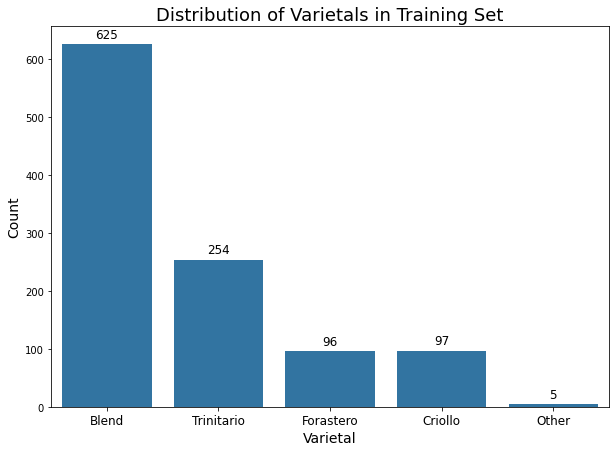

In [26]:
'Distribution of Varietals in Training Set'
labels = bean_varietal_labels.keys()
plt.figure(figsize=(10, 7))
ax = sns.countplot(data = y_train, x='varietal')
ax.set_xticklabels(labels, fontsize=12)
ax.bar_label(ax.containers[0], padding=3, fontsize=12)
plt.xlabel("Varietal", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.title('Distribution of Varietals in Training Set', fontsize=18)
plt.show()

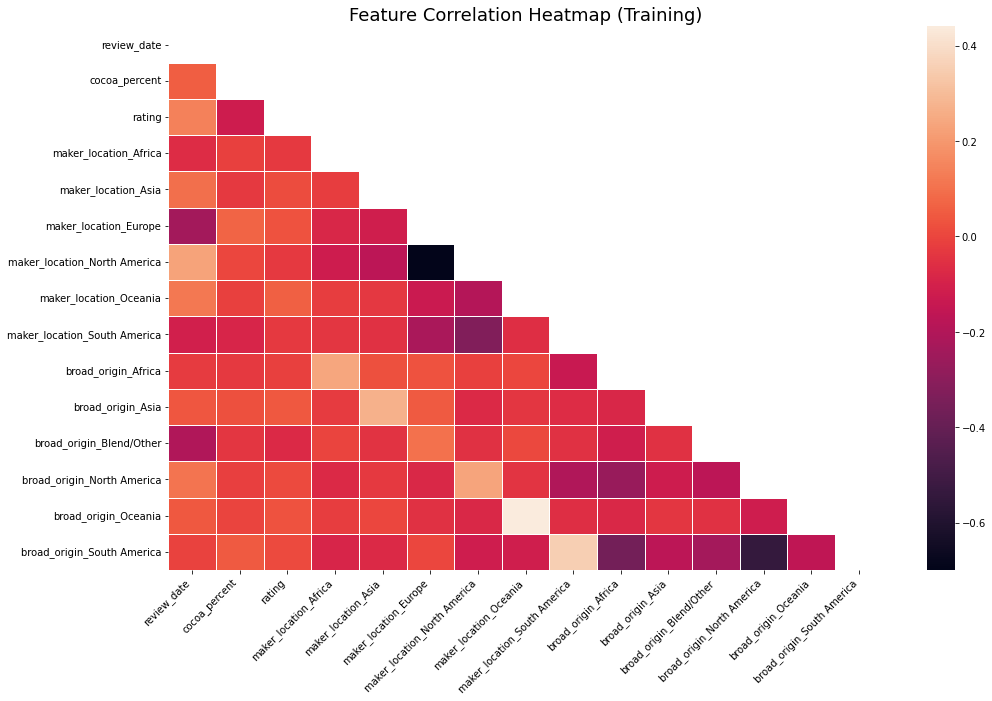

In [27]:
corr = x_train.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(16, 10))
ax = sns.heatmap(corr,mask=mask,annot=False, linewidths=.5)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.title('Feature Correlation Heatmap (Training)', fontsize=18)
plt.show()

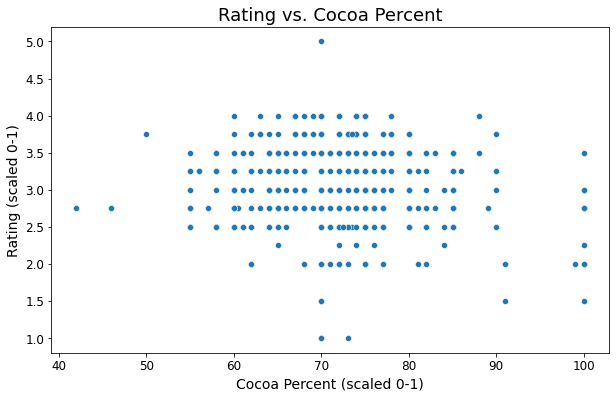

In [28]:
plt.figure(figsize=(10, 6))
# Plot the average rating per year
sns.scatterplot(x=x_train['cocoa_percent'], y=x_train['rating'])
plt.yticks(fontsize=12)
plt.xticks(fontsize=12)
plt.xlabel("Cocoa Percent (scaled 0-1)", fontsize=14)
plt.ylabel("Rating (scaled 0-1)", fontsize=14)
plt.title('Rating vs. Cocoa Percent', fontsize=18)
plt.show()

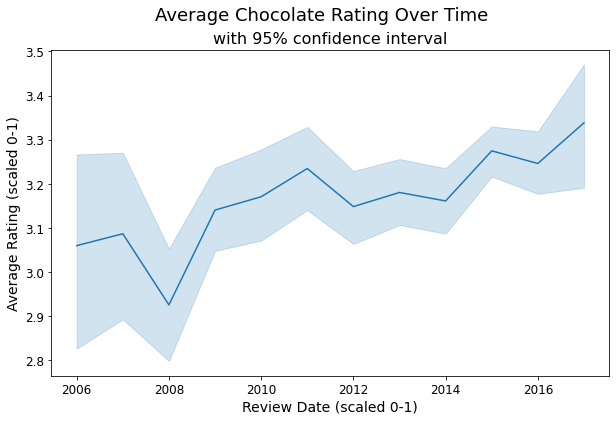

In [29]:
plt.figure(figsize=(10, 6))
sns.lineplot(x=x_train['review_date'], y=x_train['rating'])
plt.yticks(fontsize=12)
plt.xticks(fontsize=12)
plt.xlabel("Review Date (scaled 0-1)", fontsize=14)
plt.ylabel("Average Rating (scaled 0-1)", fontsize=14)
plt.suptitle("Average Chocolate Rating Over Time", fontsize=18)
plt.title('with 95% confidence interval', fontsize=16)
plt.show()

---
### Step 4: Modeling

### <span style="color:chocolate">Exercise 5:</span> Baseline model (10 points)

When dealing with classification problems, a simple baseline is to select the *majority* class (the most common label in the training set) and use it as the prediction for all inputs.

1. Implement this baseline and report the accuracy metric on the train data;

2. Implement a function that computes the Log Loss (cross-entropy loss) metric and use it to evaluate this baseline on both the train and validation data. Note: reflect on what you know about the original distribution of classes in your training data (Hint: see Assignment 4 - Exercise 8 and ``Module Demos/05 Multiclass Logistic Regression.ipynb`` in bCourses for an example).

### 1. Majority Classifier

In [30]:
class MajorityClassifier:  
    def fit(self, x, y):
        y_actual = y.iloc[:, 0]
        self.majority = y_actual.mode()[0]
        self.majority_probability = (y_actual==self.majority).mean()
        self.class_probabilities = y_actual.value_counts() / len(y)
        self.classes = self.class_probabilities.index.to_list()

    def predict(self, x):
        prediction = pd.Series(index = x.index)
        prediction = self.majority
        return prediction

    def evaluate(self, x, y):
        prediction = self.predict(x)
        actual = y.iloc[:, 0]
        accuracy = sum(prediction == actual)/len(y)
        return {'accuracy': accuracy}

    def log_loss(self, y):
        predicted_probabilities = np.tile(self.class_probabilities, (y.shape[0], 1))
        y_one_hot = np.zeros((y.shape[0], len(self.classes)))
        for i, val in enumerate(y.iloc[:, 0]):
            y_one_hot[i, val] = 1 
        log_p = np.log(predicted_probabilities)
        return -np.sum(y_one_hot*log_p) / y.shape[0]

In [31]:
classifier = MajorityClassifier()
classifier.fit(x_train, y_train)
evaluation = classifier.evaluate(x_train, y_train)
print(f"Train Data: The accuracy of the Majority Classifier is {evaluation['accuracy']:.1%}")

Train Data: The accuracy of the Majority Classifier is 58.0%


In [32]:
val_evaluation = classifier.evaluate(x_train, y_val)
print(f"Validation Data: The accuracy of the Majority Classifier is {val_evaluation['accuracy']:.1%}")

Validation Data: The accuracy of the Majority Classifier is 56.8%


In [33]:
test_evaluation = classifier.evaluate(x_train, y_val)
print(f"Test Data: The accuracy of the Majority Classifier is {test_evaluation['accuracy']:.1%}")

Test Data: The accuracy of the Majority Classifier is 56.8%


In [34]:
classifier.class_probabilities

varietal
0   0.58
1   0.24
3   0.09
2   0.09
4   0.00
Name: count, dtype: float64

### 2. Log loss

In [35]:
classifier.log_loss(y_train)

1.11374628070436

In [36]:
classifier.log_loss(y_val)

1.1626055047291217

### <span style="color:chocolate">Exercise 6:</span> Improvement over baseline with Tensorflow (10 points)

Use TensorFlow (TF) to train a multiclass logistic regression model much like you did in Assignment 4. The goal here is to build a ML model to improve over the baseline classifier. You have the flexibility to choose which features to include.

With this in mind, complete the following tasks:

1. Build and compile a multiclass classification TF model (call it model_tf). Hint: the activation function, the loss, and the evaluation metric are different compared to the binary logistic regression (see ``Module Demos/05 Multiclass Logistic Regression.ipynb`` in bCourses for an example). Set learning_rate = 0.0001 and optimizer = SGD.
2. Train model_tf using the training dataset and pass the validation data for validation. Set num_epochs = 10 and batch_size = 32.
3. Generate a plot (for the training and validation data) with the loss values on the y-axis and the epoch number on the x-axis for visualization. Make sure to include axes name and title.

If instructions for any other hyperparameters are not provided here, you are free to select your own or use the default settings.

### 1. Multiclass Logistic Regression

In [37]:
def build_model(num_features, learning_rate):

    tf.keras.backend.clear_session()
    tf.random.set_seed(1234)
    

    model = tf.keras.Sequential()
    model.add(tf.keras.Input(shape=(num_features,), name="Input"))
    model.add(tf.keras.layers.Dense(
        units=5, # for 5 classes
        use_bias=True,
        activation='softmax',
        kernel_initializer=tf.initializers.RandomNormal(stddev=0.01),
        bias_initializer=tf.initializers.RandomNormal(stddev=0.01),
        name="Output"
    ))
    model.compile(
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        optimizer=tf.keras.optimizers.SGD(learning_rate=learning_rate),
        metrics=['accuracy']
    )

    return model

### 2. Train model

In [38]:
model_tf = build_model(x_train.shape[1], 0.0001)

fitting = model_tf.fit(
    x_train_std, 
    y_train['varietal'], 
    epochs=10,
    validation_data=(x_val_std, y_val['varietal']),
    batch_size=32
)

Epoch 1/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.0946 - loss: 1.6153 - val_accuracy: 0.1198 - val_loss: 1.6133
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1005 - loss: 1.6141 - val_accuracy: 0.1253 - val_loss: 1.6122
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1078 - loss: 1.6130 - val_accuracy: 0.1393 - val_loss: 1.6111
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1162 - loss: 1.6119 - val_accuracy: 0.1504 - val_loss: 1.6100
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1227 - loss: 1.6108 - val_accuracy: 0.1588 - val_loss: 1.6089
Epoch 6/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1358 - loss: 1.6097 - val_accuracy: 0.1755 - val_loss: 1.6078
Epoch 7/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1866 - loss: 1.6086 - val_accuracy: 0.1922 - val_loss: 1.6067
Epoch 8/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2213 - loss: 1.6075 - val_accuracy: 0.2145 - val_loss:

### 3. Plot the training

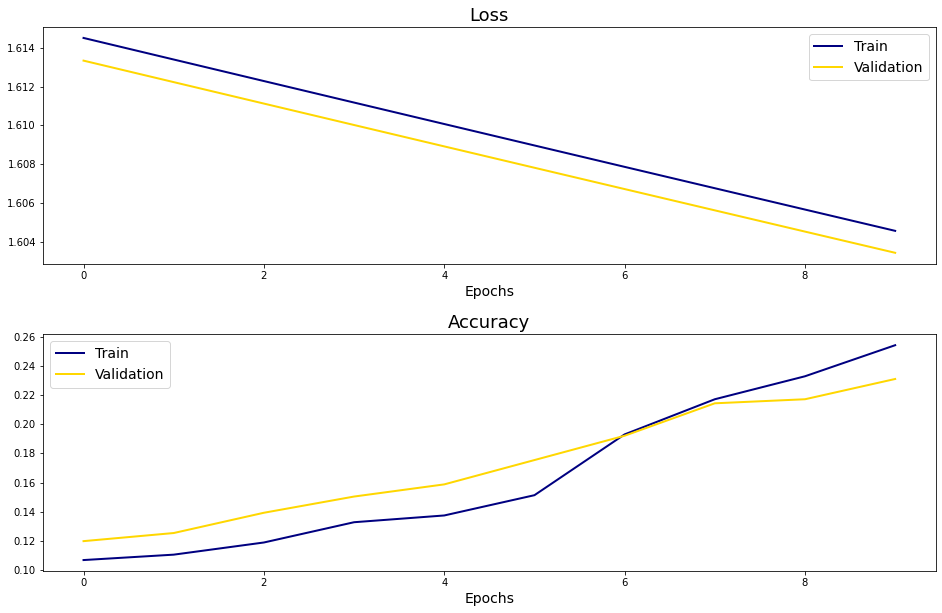

In [39]:
# grab history
history = fitting.history

# plot loss for train and validation
fig = plt.figure(figsize=(16, 10))
ax = fig.add_subplot(2, 1, 1)
plt.plot(history['loss'], lw=2, color='navy')
plt.plot(history['val_loss'], lw=2, color='gold')
plt.legend(['Train', 'Validation'], fontsize=14)
ax.set_xlabel('Epochs', size=14)
ax.set_title('Loss', size=18);

# plot accuracy for train and validation
ax = fig.add_subplot(2, 1, 2)
plt.plot(history['accuracy'], lw=2, color='navy')
plt.plot(history['val_accuracy'], lw=2, color='gold')
plt.legend(['Train', 'Validation'], fontsize=14)
ax.set_xlabel('Epochs', size=14)
ax.set_title('Accuracy', size=18);

plt.subplots_adjust(hspace=0.3)
plt.show()

---
### Step 5: Hyperparameter tuning

### <span style="color:chocolate">Exercise 7:</span> Choosing hyperparameters (10 points)

1. Fine-tune the **learning rate**, **number of epochs**, and **batch size** hyperparameters of *model_tf* to determine the setup that yields the most optimal generalization performance. Feel free to explore various values for these hyperparameters. Hint: you can manually test different hyperparameter values or you can use the [Keras Tuner](https://www.tensorflow.org/tutorials/keras/keras_tuner). 

After identifying your preferred model configuration, print the following information:

2. The first five learned parameters of the model (this should include the bias term);
3. The loss at the final epoch on both the training and validation datasets;
4. The percentage difference between the losses observed on the training and validation datasets.
5. Compare the training/validation loss of the TensorFlow model (model_tf) with the baseline model's loss. Does the TensorFlow model demonstrate an improvement over the baseline model?

In [40]:
num_features = x_train_std.shape[1]

def build_tuned_model(hp):

    tf.keras.backend.clear_session()
    tf.random.set_seed(1234)
    
    learning_rate = hp.Float('learning_rate',
                min_value=0.0001,
                max_value=0.1,
                sampling="log"
    )

    model = tf.keras.Sequential()
    model.add(tf.keras.Input(shape=(num_features,), name="Input"))
    model.add(tf.keras.layers.Dense(
        units=5, # for 5 classes
        use_bias=True,
        activation='softmax',
        kernel_initializer=tf.initializers.RandomNormal(stddev=0.01),
        bias_initializer=tf.initializers.RandomNormal(stddev=0.01),
        name="Output"
    ))
    model.compile(
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        optimizer=tf.keras.optimizers.SGD(learning_rate=learning_rate),
        metrics=['accuracy']
    )

    return model

In [41]:
tuner = kt.Hyperband(
    build_tuned_model,
    objective='val_accuracy',
    max_epochs=100,
    factor=3,
    directory='my_tuner_results',
    project_name='assignment_5'
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

tuner.search(
    x_train_std,
    y_train['varietal'].values,
    validation_data=(x_val_std, y_val['varietal'].values),
    callbacks=[early_stop]
)

Trial 254 Complete [00h 00m 25s]
val_accuracy: 0.621169924736023

Best val_accuracy So Far: 0.6239554286003113
Total elapsed time: 00h 16m 12s


In [42]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Learning rate: {best_hps.get('learning_rate')}")

best_trial = tuner.oracle.get_best_trials(num_trials=1)[0]
print(f"\nBest trial ID: {best_trial.trial_id}")
print(f"Best validation accuracy: {best_trial.score}")
print(f"Hyperparameters: {best_trial.hyperparameters.values}")

Learning rate: 0.00024030130795187017

Best trial ID: 0246
Best validation accuracy: 0.6239554286003113
Hyperparameters: {'learning_rate': 0.00024030130795187017, 'tuner/epochs': 100, 'tuner/initial_epoch': 34, 'tuner/bracket': 1, 'tuner/round': 1, 'tuner/trial_id': '0239'}


In [43]:
best_model = tuner.get_best_models(num_models=1)[0]

# Evaluate immediately (no retraining needed)
val_loss, val_acc = best_model.evaluate(x_val_std, y_val['varietal'].values)
print(f"\nValidation Loss: {val_loss:.4f}")
print(f"\nValidation Accuracy: {val_acc:.4f}")

test_loss, test_acc = best_model.evaluate(x_test_std, y_test['varietal'].values)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"\nTest Accuracy: {test_acc:.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6113 - loss: 1.4826  

Validation Loss: 1.4785

Validation Accuracy: 0.6240
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6264 - loss: 1.4744 

Test Loss: 1.4778

Test Accuracy: 0.6267


---
### Step 6: Evaluation and generalization

### <span style="color:chocolate">Exercise 8:</span> Compute metrics (10 points)

Now that you've determined the optimal set of hyperparameters, it's time to evaluate your optimized model on the test data to gauge its performance in real-world scenarios, commonly known as inference.

1. Calculate aggregate accuracy on both train and test datasets. Note: you will need to convert the vector of predicted probabilities to a class label using the argmax operation. Hint: You can utilize the <span style="color:chocolate">model.predict()</span> method provided by tf.keras. and the <span style="color:chocolate">np.max()</span> method available in NumPy.

2. Does the model demonstrate strong aggregate generalization capabilities? Provide an explanation based on your accuracy observations.

### 1. Evaluation on train

In [44]:
train_predictions = best_model.predict(x_train_std)
train_predicted_classes = np.argmax(train_predictions, axis=1)
train_actual_classes = y_train['varietal'].values
train_accuracy = np.mean(train_predicted_classes == train_actual_classes)


34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


### Evaluation on test

In [46]:
test_predictions = best_model.predict(x_test_std)
test_predicted_classes = np.argmax(test_predictions, axis=1)
test_actual_classes = y_test['varietal'].values
test_accuracy = np.mean(test_predicted_classes == test_actual_classes)


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


### 2. Generalization

In [52]:
print(f"Training Accuracy: {train_accuracy:.1%}")
print(f"Test Accuracy: {test_accuracy:.1%}")

Training Accuracy: 61.2%
Test Accuracy: 62.7%


The model generalizes well to the test data becuase it had a similar level of accuracy compared to the training performance. The test accuracy actually improves slightly compared to train (test accuracy = 62.7% vs train accuracy = 61.2%). From that perspective it is not overfit to the training data and shows a similar level of performance on test. While the absolute accuracy is only a modest performance compared to the majority classifier (57% accuracy on test), the model demonstrates that it has learned enough to show a slight gain on test data.

### <span style="color:chocolate">Exercise 9:</span> Additional metrics (10 points)

Using the test dataset:

1. Plot the confusion matrix. Identify which class the model confuses the most.

2. Determine which class has the lowest precision. What is the precision? Which class is the largest source of false positives?

3. Determine which class has the lowest recall. What is the recall? Which class is the largest source of false negatives?

### Confusion Matrix

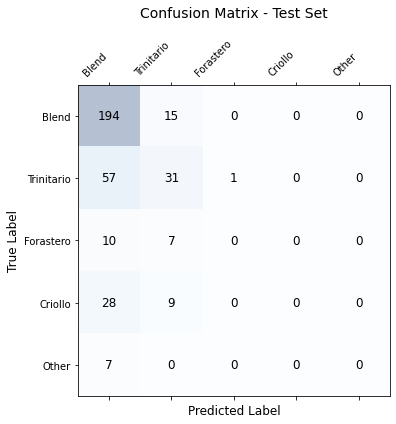

In [48]:
import numpy as np

conf_matrix = tf.math.confusion_matrix(
    y_test['varietal'].values,
    test_predicted_classes,
    num_classes=5
).numpy()

fig, ax = plt.subplots(figsize=(8, 6))  
ax.matshow(conf_matrix, cmap=plt.cm.Blues, alpha=0.3)

for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        ax.text(x=j, y=i, s=conf_matrix[i, j], va='center', ha='center', fontsize=12)

class_names = bean_varietal_labels.keys()
ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.set_yticklabels(class_names)

plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix - Test Set', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

In [49]:
print(f"Proportion of Blend predictions: {(test_predicted_classes == 0).mean():.1%}")

Proportion of Blend predictions: 82.5%


#### 1. Confusion Matrix
The model is predicting Blend 82.5% of the time, and only one time predicted a varietal that isn't Blend or Trinitario. It most often confused Trinitario for Blend, guessing Blend 57 times the true label is Trinitario. It did make 31 correct Trinitario predictions, which is the only class the model successfully guessed other than Blend.

In [50]:
for label in range(5):
    true_positives = conf_matrix[label,label]
    false_positives = sum(conf_matrix[:,label]) - true_positives
    precision = true_positives / (true_positives + false_positives)
    print(f"{list(class_names)[label]}: Precision = {precision:.1%}; False Positives = {false_positives}")

Blend: Precision = 65.5%; False Positives = 102
Trinitario: Precision = 50.0%; False Positives = 31
Forastero: Precision = 0.0%; False Positives = 1
Criollo: Precision = nan%; False Positives = 0
Other: Precision = nan%; False Positives = 0


#### 2. Precision
Forastero, Criollo, and Other other had 0% precision. These were under-represented in the training data, so the model only predicted them 1 time collectively. It did not make a single correct prediction on these classes. Instead it heavily favors guessing Blend which had 102 false positives.

In [51]:
for label in range(5):
    true_positives = conf_matrix[label,label]
    false_negatives = sum(conf_matrix[label,:]) - true_positives
    recall = true_positives / (true_positives + false_negatives)
    print(f"{list(class_names)[label]}: Recall = {recall:.1%}; False Negatives = {false_negatives}")

Blend: Recall = 92.8%; False Negatives = 15
Trinitario: Recall = 34.8%; False Negatives = 58
Forastero: Recall = 0.0%; False Negatives = 17
Criollo: Recall = 0.0%; False Negatives = 37
Other: Recall = 0.0%; False Negatives = 7


#### 3. Recall
Forastero, Criollo, and Other all had 0% recall. The largest source of false negatives is Trinitario which has 58 false negatives. The model favors guessing Blend, so the recall on Blend is 93%, but that means it guesses Blend much of the time true label is Trinitario (57 occurrences).

----
#### <span style="color:chocolate">Additional practice question</span> (not graded)

Following the approach in Assignment 4 - Exercise 12, evaluate whether your model shows any signs of unfairness. Explain your findings and propose suggestions for improvement.

The data is heavily biased toward the Blend varietal, so the model is predicting Blend 83% of the time. The model would benefit from better balance of data possibly by duplicating the non-Blend varietals.